# Análisis de resultados reales

Este notebook analiza los resultados obtenidos al aplicar los dos métodos de estimación de movimiento sobre los vídeos reales grabados para el proyecto.

Los métodos comparados son:

- diferencia de imágenes;
- flujo óptico Lucas-Kanade.

Para cada escenario real se utilizan dos tomas diferentes:

- movimiento normal;
- vídeo con ruido;
- cambio de iluminación;
- movimiento rápido.

El objetivo es comprobar si el comportamiento observado en los vídeos sintéticos se mantiene también en vídeos reales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

plots_dir = project_dir / "outputs" / "plots" / "real"
plots_dir.mkdir(parents=True, exist_ok=True)

for old_plot in plots_dir.glob("*.png"):
    old_plot.unlink()

summary_path = plots_dir / "real_experiments_summary.csv"

print("Directorio del proyecto:", project_dir)
print("Ruta del resumen real:", summary_path)
print("Existe el archivo:", summary_path.exists())

if not summary_path.exists():
    raise FileNotFoundError(
        "No se encontró el archivo de resumen. Ejecuta primero: python src/run_real_experiments.py"
    )

summary_df = pd.read_csv(summary_path)

print("Columnas:", summary_df.columns.tolist())
summary_df

Directorio del proyecto: c:\Users\34689\Desktop\Glole\U\masterus\percep
Ruta del resumen real: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_experiments_summary.csv
Existe el archivo: True
Columnas: ['scenario', 'method', 'detections', 'mean_displacement', 'median_displacement', 'p95_displacement', 'max_displacement', 'mean_area', 'mean_points_per_frame']


,scenario,method,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame
0,real_normal_1,frame_difference,98,40.895984,6.082763,231.083534,242.101219,1956.826531,NaN
1,real_normal_1,lucas_kanade,490,1.459442,0.488058,4.941953,47.789307,NaN,20.089796
2,real_normal_2,frame_difference,52,43.777043,13.928388,217.652435,384.187454,1464.519231,NaN
3,real_normal_2,lucas_kanade,336,3.575200,2.557519,9.966280,21.271498,NaN,46.616071
4,real_normal_3,frame_difference,272,37.724371,9.848858,113.459122,660.667087,1489.511029,NaN
5,real_normal_3,lucas_kanade,674,3.626797,2.931272,8.788937,122.115211,NaN,33.166172
6,real_normal_4,frame_difference,96,147.764282,78.339007,465.818289,542.196459,10347.505208,NaN
7,real_normal_4,lucas_kanade,158,1.737776,0.212003,11.136132,206.839371,NaN,47.227848
8,real_noisy_1,frame_difference,96,42.373634,6.082763,231.337734,282.347304,1962.765625,NaN
9,real_noisy_1,lucas_kanade,467,1.954650,0.965185,5.520185,48.347546,NaN,37.340471


In [2]:
def get_condition(scenario_name):
    if "normal" in scenario_name:
        return "Normal"
    if "noisy" in scenario_name:
        return "Ruido"
    if "light_change" in scenario_name:
        return "Cambio de luz"
    if "fast" in scenario_name:
        return "Movimiento rápido"
    return "Otro"


condition_order = [
    "Normal",
    "Ruido",
    "Cambio de luz",
    "Movimiento rápido",
]

method_labels = {
    "frame_difference": "Diferencia de imágenes",
    "lucas_kanade": "Lucas-Kanade",
}

summary_df["condition"] = summary_df["scenario"].apply(get_condition)

summary_df["condition"] = pd.Categorical(
    summary_df["condition"],
    categories=condition_order,
    ordered=True
)

summary_df["method_label"] = summary_df["method"].map(method_labels)

summary_df = summary_df.sort_values(["condition", "scenario", "method"])

summary_df

,scenario,method,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame,condition,method_label
0,real_normal_1,frame_difference,98,40.895984,6.082763,231.083534,242.101219,1956.826531,NaN,Normal,Diferencia de imágenes
1,real_normal_1,lucas_kanade,490,1.459442,0.488058,4.941953,47.789307,NaN,20.089796,Normal,Lucas-Kanade
2,real_normal_2,frame_difference,52,43.777043,13.928388,217.652435,384.187454,1464.519231,NaN,Normal,Diferencia de imágenes
3,real_normal_2,lucas_kanade,336,3.575200,2.557519,9.966280,21.271498,NaN,46.616071,Normal,Lucas-Kanade
4,real_normal_3,frame_difference,272,37.724371,9.848858,113.459122,660.667087,1489.511029,NaN,Normal,Diferencia de imágenes
5,real_normal_3,lucas_kanade,674,3.626797,2.931272,8.788937,122.115211,NaN,33.166172,Normal,Lucas-Kanade
6,real_normal_4,frame_difference,96,147.764282,78.339007,465.818289,542.196459,10347.505208,NaN,Normal,Diferencia de imágenes
7,real_normal_4,lucas_kanade,158,1.737776,0.212003,11.136132,206.839371,NaN,47.227848,Normal,Lucas-Kanade
8,real_noisy_1,frame_difference,96,42.373634,6.082763,231.337734,282.347304,1962.765625,NaN,Ruido,Diferencia de imágenes
9,real_noisy_1,lucas_kanade,467,1.954650,0.965185,5.520185,48.347546,NaN,37.340471,Ruido,Lucas-Kanade


In [3]:
summary_grouped = summary_df.groupby(
    ["condition", "method_label"],
    observed=True
).agg(
    detections=("detections", "mean"),
    mean_displacement=("mean_displacement", "mean"),
    median_displacement=("median_displacement", "mean"),
    p95_displacement=("p95_displacement", "mean"),
    max_displacement=("max_displacement", "mean"),
    mean_area=("mean_area", "mean"),
    mean_points_per_frame=("mean_points_per_frame", "mean"),
).reset_index()

summary_grouped

,condition,method_label,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame
0,Normal,Diferencia de imágenes,129.50,67.540420,27.049754,257.003345,457.288055,3814.590500,NaN
1,Normal,Lucas-Kanade,414.50,2.599804,1.547213,8.708326,99.503847,NaN,36.774972
2,Ruido,Diferencia de imágenes,127.50,67.587643,25.657013,272.773773,479.596735,3707.665625,NaN
3,Ruido,Lucas-Kanade,408.75,2.762135,1.572122,9.430769,146.270960,NaN,41.960404
4,Cambio de luz,Diferencia de imágenes,131.50,75.464653,21.527723,287.854678,487.727205,26000.648091,NaN
5,Cambio de luz,Lucas-Kanade,390.25,2.825945,1.752180,8.654773,173.712776,NaN,31.832246
6,Movimiento rápido,Diferencia de imágenes,135.25,91.031420,24.410835,344.277732,552.402159,6689.944079,NaN
7,Movimiento rápido,Lucas-Kanade,235.25,4.520668,2.336252,17.850101,153.869272,NaN,36.672526


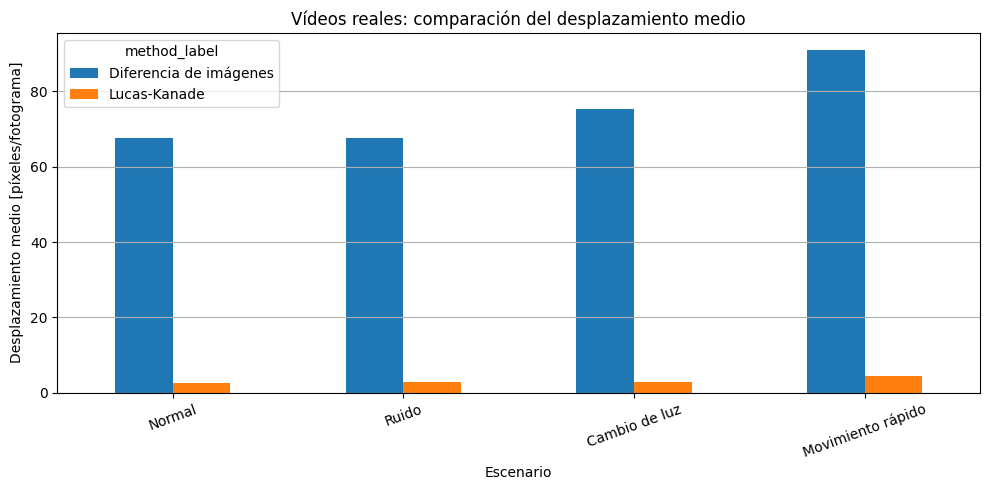

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_mean_displacement.png


In [4]:
mean_disp_plot = plots_dir / "real_mean_displacement.png"

pivot_mean = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="mean_displacement"
)

pivot_mean.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Desplazamiento medio [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Vídeos reales: comparación del desplazamiento medio")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(mean_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", mean_disp_plot)

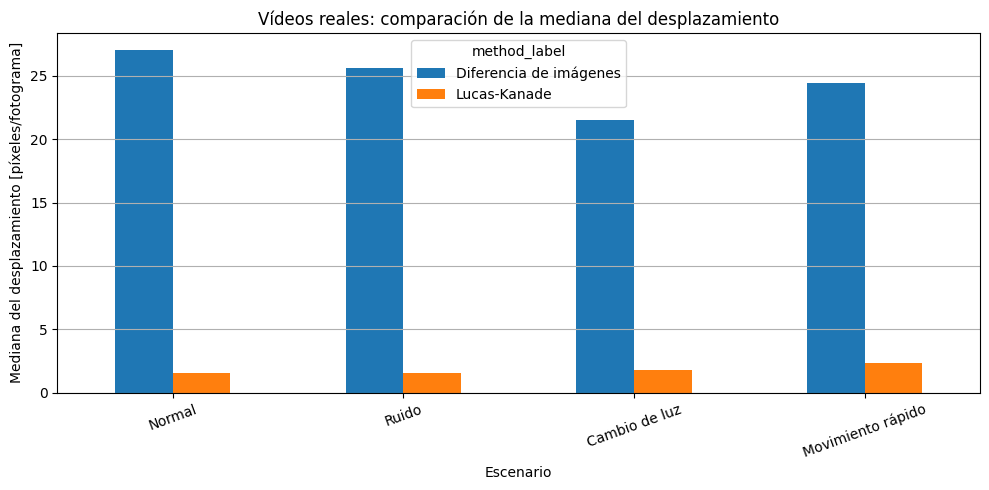

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_median_displacement.png


In [5]:
median_disp_plot = plots_dir / "real_median_displacement.png"

pivot_median = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="median_displacement"
)

pivot_median.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Mediana del desplazamiento [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Vídeos reales: comparación de la mediana del desplazamiento")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(median_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", median_disp_plot)

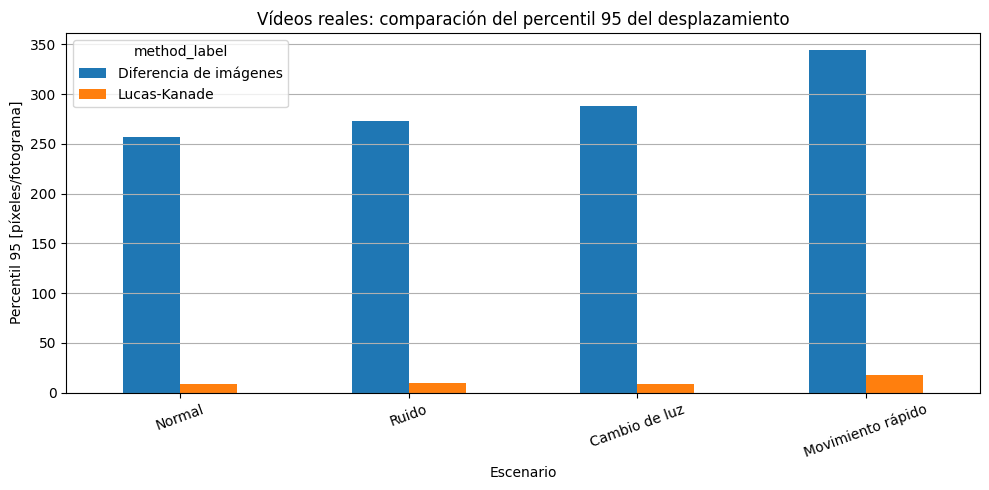

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_p95_displacement.png


In [6]:
p95_disp_plot = plots_dir / "real_p95_displacement.png"

pivot_p95 = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="p95_displacement"
)

pivot_p95.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Percentil 95 [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Vídeos reales: comparación del percentil 95 del desplazamiento")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(p95_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", p95_disp_plot)

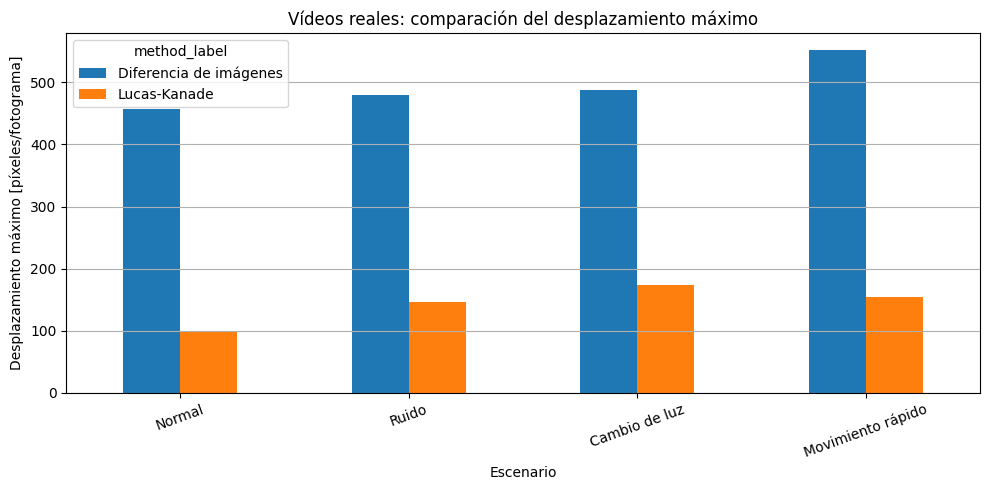

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_max_displacement.png


In [7]:
max_disp_plot = plots_dir / "real_max_displacement.png"

pivot_max = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="max_displacement"
)

pivot_max.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Desplazamiento máximo [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Vídeos reales: comparación del desplazamiento máximo")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(max_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", max_disp_plot)

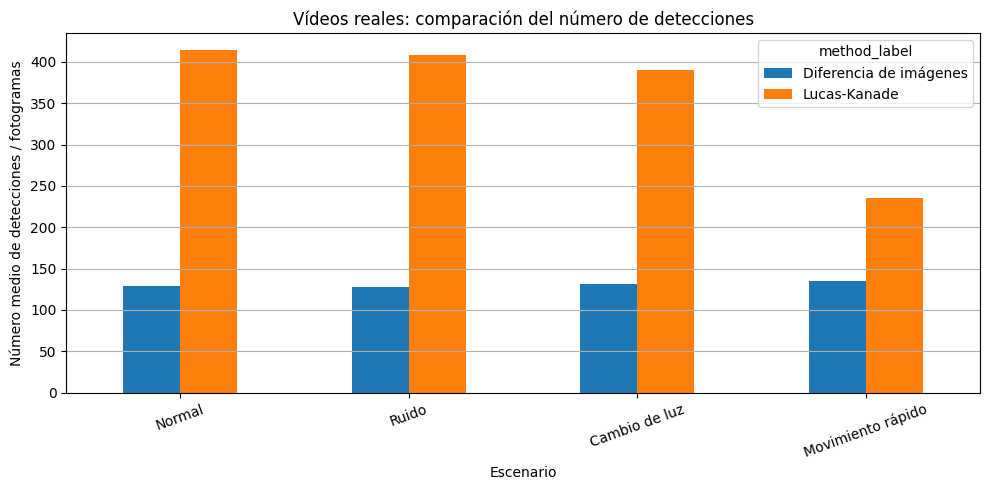

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_detections.png


In [8]:
detections_plot = plots_dir / "real_detections.png"

pivot_detections = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="detections"
)

pivot_detections.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Número medio de detecciones / fotogramas")
plt.xlabel("Escenario")
plt.title("Vídeos reales: comparación del número de detecciones")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(detections_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", detections_plot)

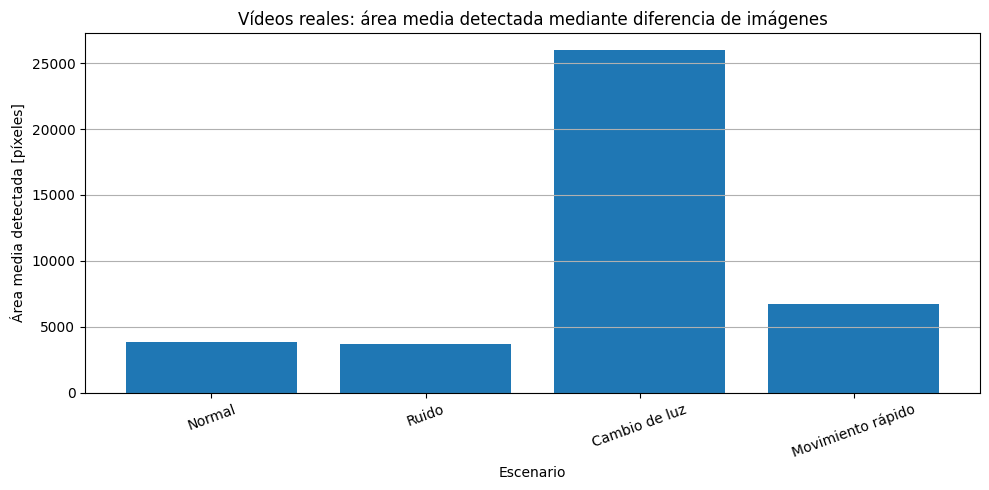

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_frame_difference_mean_area.png


In [9]:
area_plot = plots_dir / "real_frame_difference_mean_area.png"

frame_diff_df = summary_grouped[
    summary_grouped["method_label"] == "Diferencia de imágenes"
]

plt.figure(figsize=(10, 5))
plt.bar(frame_diff_df["condition"], frame_diff_df["mean_area"])

plt.ylabel("Área media detectada [píxeles]")
plt.xlabel("Escenario")
plt.title("Vídeos reales: área media detectada mediante diferencia de imágenes")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(area_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", area_plot)

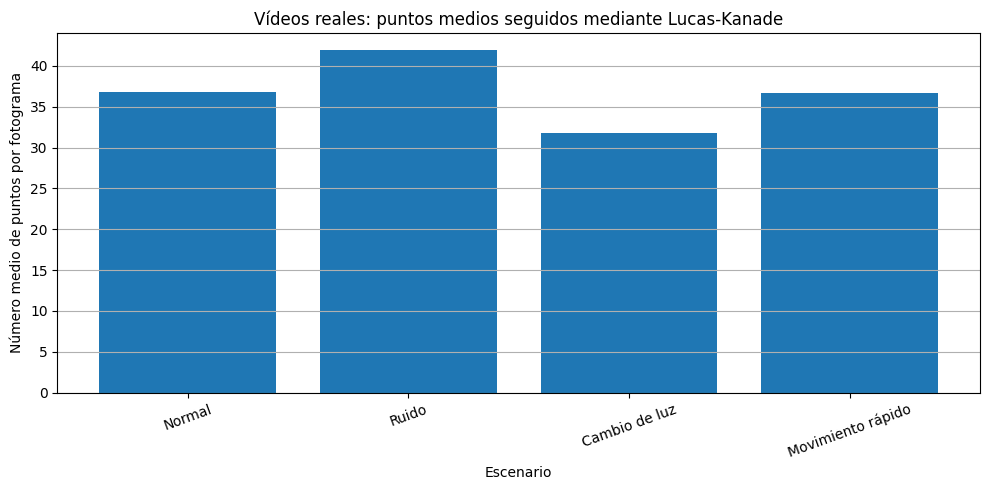

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_lucas_kanade_mean_points.png


In [10]:
points_plot = plots_dir / "real_lucas_kanade_mean_points.png"

lk_df = summary_grouped[
    summary_grouped["method_label"] == "Lucas-Kanade"
]

plt.figure(figsize=(10, 5))
plt.bar(lk_df["condition"], lk_df["mean_points_per_frame"])

plt.ylabel("Número medio de puntos por fotograma")
plt.xlabel("Escenario")
plt.title("Vídeos reales: puntos medios seguidos mediante Lucas-Kanade")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(points_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", points_plot)

## Conclusión del análisis real

Los vídeos reales permiten comprobar el comportamiento de los métodos en condiciones menos controladas que los escenarios sintéticos.

La diferencia de imágenes permite detectar regiones móviles de forma sencilla, pero puede verse afectada por sombras, cambios de iluminación, ruido o movimiento de elementos secundarios. Además, el centroide de la región detectada puede presentar saltos si la máscara de movimiento cambia bruscamente entre fotogramas.

Lucas-Kanade ofrece un seguimiento más estable de puntos característicos cuando el objeto tiene textura suficiente. Sin embargo, no detecta el objeto completo, sino puntos concretos, por lo que puede perder puntos o seguir puntos incorrectos si hay ruido, cambios de luz o movimientos rápidos.

El análisis conjunto de vídeos sintéticos y reales permite comparar ambos métodos de forma más completa y observar sus ventajas y limitaciones en distintos escenarios.